In [40]:
#Import the necessary libraries

import os
import time
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sentence_transformers import SentenceTransformer
 
import torch                          
import torch.nn as nn                 
from torch.utils.data import Dataset, DataLoader  

In [41]:
#Load data
df = pd.read_csv("yelp_restaurant_reviews.csv")
 

# Review data
print("\n── Dataset head ──")
print(df.head())
print(f"\nShape: {df.shape}")
print(f"Stars distribution:\n{df['Rating'].value_counts().sort_index()}")
 
# Drop any rows with missing Revie Text or Rating.
df = df.dropna(subset=["Review Text", "Rating"])
df["Rating"] = df["Rating"].astype(int)

 
reviews = df["Review Text"].tolist()
# Ratings are 1-5; for classification we remap to 0-4 (PyTorch expects 0-based).
labels = (df["Rating"].values - 1).astype(np.int64) # for classification


── Dataset head ──
                                            Yelp URL  Rating       Date  \
0  https://www.yelp.com/biz/sidney-dairy-barn-sidney       5  1/22/2022   
1  https://www.yelp.com/biz/sidney-dairy-barn-sidney       4  6/26/2022   
2  https://www.yelp.com/biz/sidney-dairy-barn-sidney       5   8/7/2021   
3  https://www.yelp.com/biz/sidney-dairy-barn-sidney       4  7/28/2016   
4  https://www.yelp.com/biz/sidney-dairy-barn-sidney       5  6/23/2015   

                                         Review Text  
0  All I can say is they have very good ice cream...  
1  Nice little local place for ice cream.My favor...  
2  A delicious treat on a hot day! Staff was very...  
3  This was great service and a fun crew! I got t...  
4  This is one of my favorite places to get ice c...  

Shape: (19896, 4)
Stars distribution:
Rating
1     1217
2     1280
3     2069
4     4447
5    10883
Name: count, dtype: int64


In [42]:
#Semantically embed the review texts and cache

# The csv will already be there, but the embedding cache will not on the first run.
# Cache it so that the embedding will not have to be repeated.

CSV_PATH = "yelp_restaurant_reviews.csv"
EMBED_CACHE = "embeddings_cache.npz"

if os.path.exists(EMBED_CACHE):
    print(f"\n[embed] Loading cached embeddings from {EMBED_CACHE}")
    embeddings = np.load(EMBED_CACHE)["embeddings"]
else:
    print("\n[embed] Encoding reviews — this takes a minute on CPU…")
    t0 = time.time()
    model_st = SentenceTransformer("all-MiniLM-L6-v2")
    embeddings = model_st.encode(
        reviews,
        batch_size=64,
        show_progress_bar=True,
        convert_to_numpy=True,
    )
    # Create the cache. Need to define the keyword "embeddings" to recover it from the cache
    np.savez(EMBED_CACHE, embeddings=embeddings) 
    print(f"[embed] Done in {time.time()-t0:.1f}s. Shape: {embeddings.shape}")
 
EMBED_DIM = embeddings.shape[1]   # 384 for MiniLM
print(f"Embedding dimension: {EMBED_DIM}")


[embed] Loading cached embeddings from embeddings_cache.npz
Embedding dimension: 384


In [43]:
# Split the data into a training set (80%), a validation set (10%), and a test set (10%).
X_train, X_temp, y_train, y_temp = \
    train_test_split(embeddings, labels, test_size=0.2, random_state=42, stratify=labels)

X_val, X_test, y_val, y_test = \
    train_test_split(X_temp, y_temp,
                     test_size=0.5, random_state=42, stratify=y_temp)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)
 
print(f"\nSplit sizes → train:{len(X_train)}  val:{len(X_val)}  test:{len(X_test)}")


Split sizes → train:15916  val:1990  test:1990


In [44]:
class ReviewDataset(Dataset):
    """A minimal Dataset: just wraps numpy arrays."""
 
    def __init__(self, X: np.ndarray, y: np.ndarray):
        # Convert numpy → torch tensors once, up front.
        # torch.long (int64) for classification targets.
        self.X     = torch.tensor(X,     dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
 
    def __len__(self) -> int:
        # DataLoader calls this to know the dataset size.
        return len(self.X)
 
    def __getitem__(self, idx: int):
        # DataLoader calls this for each sample.
        # Return a dict — clean and explicit.
        return {
            "x": self.X[idx],     
            "y": self.y[idx],
        }
 
BATCH_SIZE = 64
 
train_ds = ReviewDataset(X_train, y_train)
val_ds   = ReviewDataset(X_val, y_val)
test_ds  = ReviewDataset(X_test, y_test)
 
# shuffle=True only for training; deterministic for val/test.
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)
 
# Quick peek at one batch to verify shapes.
batch = next(iter(train_dl))
print(f"\nOne training batch:")
print(f"  x     shape: {batch['x'].shape}")      # (64, 384)

print(f"  y shape: {batch['y'].shape}")   # (64,)


One training batch:
  x     shape: torch.Size([64, 384])
  y shape: torch.Size([64])


In [45]:
class NNClassifier(nn.Module):
 
    def __init__(self, input_dim: int, num_classes: int = 5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),          # normalise activations per batch
            nn.ReLU(),
            nn.Dropout(0.3),              # randomly zero 30% of neurons during training
            nn.Linear(256, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes),   # 5 logits, one per star rating
            # No Softmax here — CrossEntropyLoss applies it internally.
        )
 
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)
 
model = NNClassifier(EMBED_DIM)
print(f"\nClassifier model:\n{model}")
n_params = sum(p.numel() for p in model.parameters())
print(f"Parameters: {n_params:,}")


Classifier model:
NNClassifier(
  (net): Sequential(
    (0): Linear(in_features=384, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=5, bias=True)
  )
)
Parameters: 115,973


In [46]:
# Create the loss function and optimization algorithm to be used in the NN.

# Compute class weights inversely proportional to frequency to 
# account for prior distribution.
counts = np.bincount(y_train)
weights = 1.0 / counts
weights = weights / weights.sum() * len(counts)  # normalize
class_weights = torch.tensor(weights, dtype=torch.float32)

loss_fcn = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [47]:
def train_one_epoch(model, loader, loss_fcn, optimizer):
    model.train()
    total_loss = 0.0
 
    for batch in loader:
        x = batch["x"]
        y = batch["y"]
 
        logits = model(x)
        loss   = loss_fcn(logits, y)  # CrossEntropy takes (logits, targets)
 
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
 
        total_loss += loss.item() * len(x)
 
    return total_loss / len(loader.dataset)

def evaluate(model, loader, loss_fcn):
    """Return average loss and accuracy on a loader."""
    model.eval()
    total_loss, correct = 0.0, 0
 
    with torch.no_grad():
        for batch in loader:
            x, y = batch["x"], batch["y"]
            logits = model(x)
            total_loss += loss_fcn(logits, y).item() * len(x)
            # argmax gives the predicted class index.
            correct += (logits.argmax(dim=1) == y).sum().item()
 
    n = len(loader.dataset)
    return total_loss / n, correct / n

In [48]:
EPOCHS = 5

# The number of EPOCHS needs to be adjusted.  In this case
# the accuracy on the validation set starts to increase
# after the sixth epoch, and the loss function on the 
# validation set continues increasing even as it decreases
# on the training set, which indicates overgeneralization.

print("\n" + "="*60)
print("Training Star Classifier")
print("="*60)
 
for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch(model, train_dl, loss_fcn, optimizer)
    val_loss, val_acc = evaluate(model, val_dl, loss_fcn)
    print(f"Epoch {epoch:2d}/{EPOCHS} | "
          f"train loss: {train_loss:.4f} | "
          f"val loss: {val_loss:.4f} | val acc: {val_acc:.3f}")
 
test_loss, test_acc = evaluate(model, test_dl, loss_fcn)
print(f"\n[Classifier] Test loss: {test_loss:.4f}  Test acc: {test_acc:.3f}")
 


Training Star Classifier
Epoch  1/5 | train loss: 1.2731 | val loss: 1.0973 | val acc: 0.573
Epoch  2/5 | train loss: 1.1128 | val loss: 1.0678 | val acc: 0.589
Epoch  3/5 | train loss: 1.0649 | val loss: 1.0598 | val acc: 0.592
Epoch  4/5 | train loss: 1.0215 | val loss: 1.0438 | val acc: 0.596
Epoch  5/5 | train loss: 0.9900 | val loss: 1.0659 | val acc: 0.577

[Classifier] Test loss: 1.1020  Test acc: 0.561


Mean Absolute Error: 0.5945
On average, the model is off by 0.59 stars.
--- PyTorch NN Classification Report ---
              precision    recall  f1-score   support

      1 Star       0.44      0.55      0.49       122
     2 Stars       0.27      0.55      0.37       128
     3 Stars       0.33      0.35      0.34       207
     4 Stars       0.39      0.44      0.42       445
     5 Stars       0.83      0.65      0.73      1088

    accuracy                           0.56      1990
   macro avg       0.45      0.51      0.47      1990
weighted avg       0.62      0.56      0.58      1990



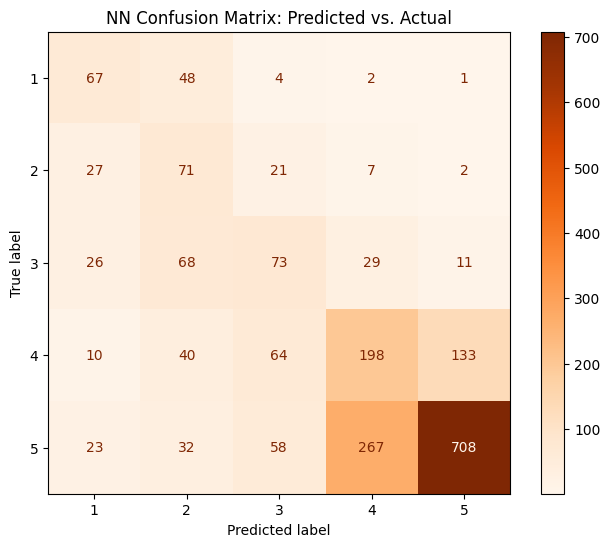

In [49]:
import torch
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, mean_absolute_error
import matplotlib.pyplot as plt


# Convert X_test to a tensor and extract predictions.
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

model.eval()  # Set to evaluation mode
with torch.no_grad():
    # Pass data through model
    logits = model(X_test_tensor)
    # Get the index of the highest logit for each sample
    pytorch_preds = torch.argmax(logits, dim=1).numpy()

mae = mean_absolute_error(y_test, pytorch_preds)

print(f"Mean Absolute Error: {mae:.4f}")
print(f"On average, the model is off by {mae:.2f} stars.")

# 3. Print Report
print("--- PyTorch NN Classification Report ---")
target_names = ["1 Star", "2 Stars", "3 Stars", "4 Stars", "5 Stars"]
print(classification_report(y_test, pytorch_preds, target_names=target_names))

cm = confusion_matrix(y_test, pytorch_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["1", "2", "3", "4", "5"])

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Oranges', ax=ax)
plt.title('NN Confusion Matrix: Predicted vs. Actual')
plt.show()

